### 2. Regression Experiments

Esse notebook demostra a exploração e transformação do target de categorias para faixas numéricas discretizadas, utilizando o ponto médio de cada categoria. O objetivo desse notebook foi tentar gerar 

In [44]:
# IMPORTANDO PANDAS E MATPLOTLIB
import pandas as pd
import numpy as np

In [1]:
# CRIANDO UM DATAFRAME A PARTIR DOS DADOS
from src.data_loading import load_data
from src.preprocessing import prepare_data

df = load_data('..\data\processed\prepared_dataset.csv')
df = prepare_data(df)


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Ian Guilherme Dev\AppData\Local\Temp\ipykernel_8628\890996766.py:5: SyntaxWarning: invalid escape sequence '\d'
  df = load_data('..\data\processed\prepared_dataset.csv')


### 2.1. Transformando o dado categórico para númerico discretizado

Quero construir um modelo de regressão (que prevê um valor numérico), então prefiro usar o valor médio de cada categoria.

In [3]:
df['categorias_target'].value_counts()

categorias_target
de R$ 12.001/mês a R$ 20.000/mês    1141
de R$ 8.001/mês a R$ 12.000/mês     1064
de 3.001/mês a R$ 6.000/mês          856
de R$ 6.001/mês a R$ 8.000/mês       644
acima de R$ 20.000/mês               595
até R$ 3.000/mês                     422
Name: count, dtype: int64

In [5]:
categoria_para_valor = {
    'até R$ 3.000/mês': 3000, 
    'de 3.001/mês a R$ 6.000/mês': 4500,     
    'de R$ 6.001/mês a R$ 8.000/mês': 7000,      
    'de R$ 8.001/mês a R$ 12.000/mês': 10000,  
    'de R$ 12.001/mês a R$ 20.000/mês': 16000,    
    'acima de R$ 20.000/mês': 20000
}

df['categorias_target'] = df['categorias_target'].map(categoria_para_valor)

<Axes: xlabel='categorias_target'>

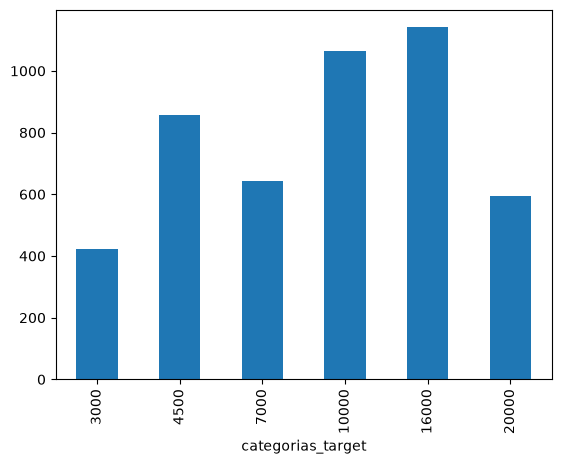

In [9]:
df_tratado = df.dropna(subset=['categorias_target'])
df['categorias_target'].isna().sum()

# VERIFICANDO COMO FICA
df['categorias_target'].value_counts().sort_index().plot(kind='bar')

Gerando copia do train_set para analisar a correlação entre features e o target

In [25]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_tratado, 
                                       test_size=0.2, 
                                       stratify=df_tratado['categorias_target'],
                                       random_state=42)

In [26]:
survey_data = train_set.copy()
survey_data


,Unnamed: 0,idade,uf_onde_mora,nivel_de_ensino,area_formacao,situacao_trabalho,setor,cargo_atual,nivel_senioridade,tempo_experiencia,...,MySQL,Google_BigQuery,SQL_Server,Databricks,PostgreSQL,nao_utilizamos_cloud,Google_cloud,Azure,AWS,categorias_target
2109,2314,30,SP,Graduação/Bacharelado,Estatística/ Matemática / Matemática Computaci...,Empregado (CLT),Finanças ou Bancos,Analista de Dados/Data Analyst,Sênior,Menos de 1 ano,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,7000
2168,2384,30,SP,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Área de Consultoria,Engenheiro de Dados/Data Engineer/Data Architect,Pleno,Não tive experiência na área de TI/Engenharia ...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10000
2280,2500,31,SP,Pós-graduação,Outras Engenharias (não incluir engenharia de ...,Empregado (CLT),Agronegócios,Outra Opção,Sênior,de 3 a 4 anos,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,10000
3601,3953,36,MG,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Tecnologia/Fábrica de Software,Desenvolvedor/ Engenheiro de Software/ Analist...,Sênior,de 7 a 10 anos,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,16000
4326,4746,43,SP,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Finanças ou Bancos,Engenheiro de Dados/Data Engineer/Data Architect,Sênior,Não tive experiência na área de TI/Engenharia ...,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3338,34,PR,Pós-graduação,Marketing / Publicidade / Comunicação / Jornal...,Empregado (CLT),Finanças ou Bancos,Analista de BI/BI Analyst,Sênior,Não tive experiência na área de TI/Engenharia ...,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,10000
587,667,25,DF,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Indústria,Analista de Dados/Data Analyst,Júnior,de 1 a 2 anos,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,4500
4699,5183,57,SP,Mestrado,Economia/ Administração / Contabilidade / Fina...,Servidor Público,Setor Público,Nao Informado,Nao Informado,Não tive experiência na área de TI/Engenharia ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16000
2264,2483,31,RN,Pós-graduação,Outras Engenharias (não incluir engenharia de ...,Empregado (CLT),Área da Saúde,Nao Informado,Nao Informado,Não tive experiência na área de TI/Engenharia ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000


In [27]:
correaltion = survey_data.corr(numeric_only=True)
correaltion['categorias_target'].sort_values(ascending=False)

categorias_target       1.000000
Unnamed: 0              0.429691
idade                   0.397041
Python                  0.197246
AWS                     0.193237
SQL                     0.152802
Google_BigQuery         0.123875
PostgreSQL              0.120935
Databricks              0.116283
Google_cloud            0.110314
Java                    0.067183
JS                      0.033821
R                       0.010431
Oracle                  0.007160
MySQL                  -0.005212
Azure                  -0.006385
SQL_Server             -0.019449
nao_utilizamos_cloud   -0.094399
Name: categorias_target, dtype: float64

In [28]:
survey_data.groupby("nivel_senioridade")['categorias_target'].median().sort_values()

nivel_senioridade
Júnior            4500.0
Pleno             7000.0
Nao Informado    16000.0
Sênior           16000.0
Name: categorias_target, dtype: float64

In [29]:
analysis_features = ["cargo_atual","situacao_trabalho","setor","uf_onde_mora",
                     "nivel_de_ensino","area_formacao",'tempo_experiencia']
for an in analysis_features:
    group = survey_data.groupby(an)['categorias_target'].median().sort_values()
    print('MÉDIA SALARIAL POR: ', group)
    print('-' * 100)


MÉDIA SALARIAL POR:  cargo_atual
Analista de BI/BI Analyst                                       4500.0
Analista de Suporte/Analista Técnico                            4500.0
Outra Opção                                                     4500.0
Analista de Dados/Data Analyst                                  7000.0
Estatístico                                                     7000.0
Outras Engenharias (não inclui dev)                             7000.0
Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas     7000.0
Analista de Negócios/Business Analyst                           7000.0
Professor/Pesquisador                                           7000.0
Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)      10000.0
Cientista de Dados/Data Scientist                              10000.0
Analytics Engineer                                             10000.0
Engenheiro de Machine Learning/ML Engineer/AI Engineer         10000.0
Engenheiro de Dados/Data Engineer/Data Archi

Vou remover as categorias
- Desempregado e não estou buscando recolocação                         7
- Vivo fora do Brasil e trabalho para empresa de fora do Brasil         4

por serem pouco representativas e introduzir ruído no modelo desnecessáriamente, além disso pois removi anteriormente todas as linhas de pessoas que não moram no Brasil. Logo um ruído desnecessário foi adicionado ao projeto.

Analisando se todas as 980 são pessoas em comum

In [30]:
python_bool = survey_data['Python'].isna()

amostragem = ['nivel_senioridade', 'cargo_atual', 'SQL', 'Python']

survey_data.loc[python_bool, amostragem].isna().all(axis=1).sum()

np.int64(0)

In [31]:
# TRADUZIR: Grupo A: sem cargo (os 809)
grupo_a = survey_data["cargo_atual"].isna()

# TRADUZIR: Grupo B: sem stack MAS com cargo (os 171)
grupo_b = survey_data["Python"].isna() & survey_data["cargo_atual"].notna()

print("=== GRUPO A (sem cargo, 809) ===")
print("Quantos:", grupo_a.sum())
print("Salário mediano:", survey_data.loc[grupo_a, 'categorias_target'].median())
print("Situação de trabalho:")
print(survey_data.loc[grupo_a, "situacao_trabalho"].value_counts())

print("\n=== GRUPO B (sem stack, com cargo, 171) ===")
print("Quantos:", grupo_b.sum())
print("Salário mediano:", survey_data.loc[grupo_b, 'categorias_target'].median())
print("Cargos:")
print(survey_data.loc[grupo_b, "cargo_atual"].value_counts().head(10))

=== GRUPO A (sem cargo, 809) ===
Quantos: 0
Salário mediano: nan
Situação de trabalho:
Series([], Name: count, dtype: int64)

=== GRUPO B (sem stack, com cargo, 171) ===
Quantos: 990
Salário mediano: 16000.0
Cargos:
cargo_atual
Nao Informado                                                  815
Outra Opção                                                     79
Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas     31
Analista de Suporte/Analista Técnico                            27
Outras Engenharias (não inclui dev)                              8
Professor/Pesquisador                                            6
Analista de Dados/Data Analyst                                   4
Analista de Negócios/Business Analyst                            4
Engenheiro de Dados/Data Engineer/Data Architect                 4
Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)        3
Name: count, dtype: int64


In [33]:
survey_data['nivel_senioridade'].isna().sum()

np.int64(0)

## Plano de preparação dos dados (pipeline)

TARGET:
- salario_target já convertido (faixa → ponto médio)
- Considerar log-transform (cauda pesada) via TransformedTargetRegressor

FEATURES NUMÉRICAS (idade, tempo_experiencia):
- Imputar NaN (mediana)
- StandardScaler

FEATURES BINÁRIAS (stack: linguagens, bancos, clouds):
- Imputar NaN com 0

FEATURES CATEGÓRICAS (cargo, senioridade, setor, uf, formação, etc.):
- Imputar NaN com "Não informado"
- OneHotEncoder (handle_unknown="ignore")

REMOÇÕES PRÉ-SPLIT (regras de escopo):
- "Vivo fora do Brasil"

## 2.2. Refazendo o Train-Set

SEPARANDO TARGET DAS FEATURES

In [36]:
y_train = train_set['categorias_target'].copy()
X_train = train_set.drop(columns='categorias_target')

## 2.3. Limpando Data

In [37]:
# TRADUZIR: CATEGORIAS
num_list = ['idade']

cat_ordinal_list = ['nivel_de_ensino',
                    'nivel_senioridade',
                    'tempo_experiencia']

cat_one_hot_list = [ 'uf_onde_mora', 
                     'area_formacao', 'situacao_trabalho',
                     'setor', 'cargo_atual']

bin_list = ['JS', 'Java', 'R', 'Python',
       'SQL', 'Oracle', 'MySQL', 'Google_BigQuery', 'SQL_Server', 'Databricks',
       'PostgreSQL', 'nao_utilizamos_cloud', 'Google_cloud', 'Azure', 'AWS']

**ESTRATEGIAS PARA CADA TIPO DE DADO**

- NUMERICO: SimpleImputer -> StandardScaler
- CATEGÓRICO: SimpleImputer -> Encoding

In [38]:
X_train['nivel_de_ensino'].unique()

<StringArray>
[     'Graduação/Bacharelado',              'Pós-graduação',
     'Estudante de Graduação',                   'Mestrado',
           'Doutorado ou Phd', 'Não tenho graduação formal',
       'Prefiro não informar']
Length: 7, dtype: str

In [39]:
X_train['nivel_senioridade'].unique()

<StringArray>
['Sênior', 'Pleno', 'Júnior', 'Nao Informado']
Length: 4, dtype: str

In [40]:
X_train['tempo_experiencia'].unique()

<StringArray>
[                                                                                         'Menos de 1 ano',
 'Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados',
                                                                                           'de 3 a 4 anos',
                                                                                          'de 7 a 10 anos',
                                                                                           'de 1 a 2 anos',
                                                                                         'Mais de 10 anos',
                                                                                           'de 5 a 6 anos']
Length: 7, dtype: str

In [41]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# TRADUZIR: NAO TEM NaN na idade
pipeline_num = make_pipeline(StandardScaler())

pipeline_cat_ordinal = make_pipeline(SimpleImputer(strategy='constant', 
                                           fill_value='Nao Informado'),
                                     OrdinalEncoder(categories=[
                                         ['Prefiro não informar', 'Não tenho graduação formal',
                                          'Estudante de Graduação', 'Graduação/Bacharelado',
                                          'Pós-graduação', 'Mestrado', 'Doutorado ou Phd' ],
                                          ['Nao Informado', 'Júnior', 'Pleno', 'Sênior'],
                                          ['Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados',
                                           'Menos de 1 ano', 'de 1 a 2 anos','de 3 a 4 anos','de 5 a 6 anos','de 7 a 10 anos','Mais de 10 anos']
                                     ]))

pipeline_cat_one_hot = make_pipeline(SimpleImputer(strategy='constant', 
                                           fill_value='Nao Informado'),
                                     OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))

pipeline_bin = make_pipeline(SimpleImputer(strategy='constant', 
                                          fill_value=0))

GERANDO O COLUMNTRANSFORMER

In [42]:
preprocessing = ColumnTransformer([
    ("num", pipeline_num, num_list),
    ("cat_ord", pipeline_cat_ordinal, cat_ordinal_list),
    ("cat_one_hot", pipeline_cat_one_hot, cat_one_hot_list),
    ("bin", pipeline_bin, bin_list),
])


In [45]:
# TRADUZIR: APLICANDO AO X_TRAIN

X_preprocessing = pd.DataFrame(preprocessing.fit_transform(X_train),
                               columns=preprocessing.get_feature_names_out(),
                               index=X_train.index)

In [46]:
print(X_preprocessing.shape)
print(X_preprocessing.columns.tolist()[:20])  # primeiros nomes pra inspecionar

(3777, 98)
['num__idade', 'cat_ord__nivel_de_ensino', 'cat_ord__nivel_senioridade', 'cat_ord__tempo_experiencia', 'cat_one_hot__uf_onde_mora_AL', 'cat_one_hot__uf_onde_mora_AM', 'cat_one_hot__uf_onde_mora_AP', 'cat_one_hot__uf_onde_mora_BA', 'cat_one_hot__uf_onde_mora_CE', 'cat_one_hot__uf_onde_mora_DF', 'cat_one_hot__uf_onde_mora_ES', 'cat_one_hot__uf_onde_mora_GO', 'cat_one_hot__uf_onde_mora_MA', 'cat_one_hot__uf_onde_mora_MG', 'cat_one_hot__uf_onde_mora_MS', 'cat_one_hot__uf_onde_mora_MT', 'cat_one_hot__uf_onde_mora_Nao Informado', 'cat_one_hot__uf_onde_mora_PA', 'cat_one_hot__uf_onde_mora_PB', 'cat_one_hot__uf_onde_mora_PE']


### 2.4. Comparando Modelos de Regressão com Baseline

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

reg_dummy = DummyRegressor(strategy='median')
lin_model = make_pipeline(preprocessing, LinearRegression())
tree_decision_model = make_pipeline(preprocessing, DecisionTreeRegressor())
random_forest_model = make_pipeline(preprocessing, RandomForestRegressor())

select_models = [reg_dummy, lin_model, tree_decision_model, random_forest_model]

for model in select_models:
    cross_val_model = -cross_val_score(model,
                                    X_train,
                                    y_train,
                                    scoring='neg_root_mean_squared_error', 
                                    cv=5)
    print(f"MEDIAN: {cross_val_model.mean():.2f}\nSTANDARD DEVIATION: {cross_val_model.std():.2f}\n")

MEDIAN: 5690.36
STANDARD DEVIATION: 101.58

MEDIAN: 3466.55
STANDARD DEVIATION: 36.06

MEDIAN: 4638.15
STANDARD DEVIATION: 139.58

MEDIAN: 3423.29
STANDARD DEVIATION: 58.95



MODELO ESCOLHIDO FOI: Random Forest (modelo mais promissor no que se refere a fine-tuning, pelo alto número de parametros)

In [48]:
from sklearn.compose import TransformedTargetRegressor

transform_target = TransformedTargetRegressor(random_forest_model,
                                              func=np.log,
                                              inverse_func=np.exp)

cross_val_model_log = -cross_val_score(transform_target,
                                X_train,
                                y_train,
                                scoring='neg_root_mean_squared_error', 
                                cv=5)
print(cross_val_model_log.mean(), cross_val_model_log.std())

3515.248834584101 75.13691628580723


#### DADO IMPORTANTE:

Testei log-transform no target para lidar com a cauda pesada salarial, mas não houve melhora (RMSE 5.604 → 5.628). Combinado com a convergência de modelos distintos para ~5.600, concluo que o erro é limitado pela discretização do target (faixas convertidas em pontos médios), não pela modelagem. O piso de erro é estrutural.

In [49]:
random_forest_model.fit(X_train, y_train)
feature_importances = random_forest_model.named_steps['randomforestregressor'].feature_importances_
df_feature_importances = pd.DataFrame(feature_importances,
                                      index=preprocessing.get_feature_names_out())
df_feature_importances.sort_values(by=0 ,ascending=False) #by representa a coluna de referência

,0
cat_ord__nivel_senioridade,0.403739
cat_one_hot__cargo_atual_Nao Informado,0.123387
num__idade,0.070710
cat_ord__nivel_de_ensino,0.032998
cat_ord__tempo_experiencia,0.029632
...,...
cat_one_hot__uf_onde_mora_PA,0.000203
cat_one_hot__uf_onde_mora_PI,0.000171
cat_one_hot__uf_onde_mora_TO,0.000145
cat_one_hot__uf_onde_mora_Nao Informado,0.000120


### CONCLUSÕES IMPORTANTES A PARTIR DESSA ANALISE DE FEATURES IMPORTANCE

1. A senioridade ainda lidera como feature mais importante para determinar o salário do profissional em TI ( contrariando a crença que a stack é mais importante ).


2. Cargo Atual Não informado: DECISÃO DE PROJETO VALIDADA!
    - Antes dessa confirmação haviamos chegado na conclusão de que haviam 890 NaN no cargo atual que implicavam na nulidade do preenchimento das stacks, mas também se enquadravam como um grupo de alto salário. Minha decisão foi deixar esses NaNs e transforma-los em uma categoria chamada "Não Informado" para confirmar se ela também não tinha importancia na qualidade preditiva no meu modelo.
    - Após a ultima analise ela foi elencada como 2º feature mais relevante, logo isso significa que a decisão de criar essa categoria foi validada positivamente.

#### COMPARANDO PREVISÃO E ERROS POR FAIXA SALARIAL

In [50]:
from sklearn.model_selection import cross_val_predict

predicts_modelo = cross_val_predict(random_forest_model,
                                    X_train,
                                    y_train,
                                    cv=5)



In [51]:
absolute_error = np.abs(predicts_modelo - y_train)

df_error = pd.DataFrame({
    'predicts_modelo': predicts_modelo,
    'targets_reais': y_train,
'absolute_error': absolute_error
})


df_error.groupby("targets_reais")["absolute_error"].agg(["mean", "count"])

,mean,count
targets_reais,,
3000,1633.867458,337
4500,2139.679875,685
7000,2307.811003,515
10000,2694.223267,851
16000,2566.541438,913
20000,3688.804622,476


A análise de erros revelou que o modelo de regressão erra pouco nas faixas centrais (~R$ 2.500) mas catastroficamente nas faixas altas (R$ 16.900 de erro na faixa de R$ 40.000+), subestimando sistematicamente salários altos. Isso ocorre porque a regressão 'puxa' previsões em direção à média, falhando em faixas extremas com poucos exemplos. Essa limitação estrutural motivou a reformulação do problema como classificação ordinal, que trata cada faixa como classe e permite técnicas de balanceamento para as faixas raras.

### 2.5. APLICANDO NO TEST SET FINAL E VERIFICANDO O DESEMPENHO DO MODELO 

In [53]:
# TRADUZIR: separando o test set

y_test = test_set['categorias_target'].copy()
X_test = test_set.drop(columns='categorias_target')

In [54]:
from sklearn.metrics import root_mean_squared_error 

random_forest_model.fit(X_train, y_train)
predicts_model = random_forest_model.predict(X_test)

rsme_final = root_mean_squared_error(y_test, predicts_model)
rsme_final

3353.5132482126387